# Multi-Metric Evaluation using GridSearchCV

## Problem Name
**Demonstration of Multi-Metric Evaluation using GridSearchCV in Scikit-learn**

This notebook uses the Iris dataset and Random Forest Classifier to evaluate multiple metrics: **ROC AUC** and **Accuracy**.

## What we will do
1. Load the Iris dataset.
2. Define Accuracy and ROC AUC as evaluation metrics.
3. Create a Random Forest classifier.
4. Use GridSearchCV to test different `min_samples_split` values.
5. Select the best model using ROC AUC.
6. Display the best parameters and scores.
7. Visualize training and testing performance.

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, make_scorer
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

## 1. Load the Iris Dataset

In [2]:
# Load the Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

print('Features shape:', X.shape)
print('Target shape:', y.shape)
print('Target classes:', np.unique(y))

Features shape: (150, 4)
Target shape: (150,)
Target classes: [0 1 2]


## 2. Set Evaluation Metrics

In [3]:
# Multiple evaluation metrics
scoring = {
    'AUC': 'roc_auc_ovr',
    'Accuracy': make_scorer(accuracy_score)
}

print('Scoring metrics:', scoring)

Scoring metrics: {'AUC': 'roc_auc_ovr', 'Accuracy': make_scorer(accuracy_score, response_method='predict')}


## 3. Create Random Forest Classifier

In [4]:
rf_classifier = RandomForestClassifier(random_state=42)
print(rf_classifier)

RandomForestClassifier(random_state=42)


## 4. GridSearchCV

In [5]:
# Search different min_samples_split values
param_grid = {
    'min_samples_split': range(2, 43, 5)
}

grid_search = GridSearchCV(
    estimator=rf_classifier,
    param_grid=param_grid,
    scoring=scoring,
    refit='AUC',
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X, y)

results = grid_search.cv_results_

## 5. Best Parameters and Scores

In [6]:
print('Best Parameters:')
print(grid_search.best_params_)

print('\nBest ROC AUC Score:')
print(grid_search.best_score_)

print('\nBest Estimator:')
print(grid_search.best_estimator_)

Best Parameters:
{'min_samples_split': 27}

Best ROC AUC Score:
0.994

Best Estimator:
RandomForestClassifier(min_samples_split=27, random_state=42)


## 6. View Grid Search Results

In [7]:
for i, value in enumerate(results['param_min_samples_split']):
    print(
        'min_samples_split =', value,
        '| Test AUC =', round(results['mean_test_AUC'][i], 4),
        '| Test Accuracy =', round(results['mean_test_Accuracy'][i], 4)
    )

min_samples_split = 2 | Test AUC = 0.9927 | Test Accuracy = 0.9667
min_samples_split = 7 | Test AUC = 0.9927 | Test Accuracy = 0.9667
min_samples_split = 12 | Test AUC = 0.9927 | Test Accuracy = 0.9667
min_samples_split = 17 | Test AUC = 0.9927 | Test Accuracy = 0.9667
min_samples_split = 22 | Test AUC = 0.9933 | Test Accuracy = 0.9667
min_samples_split = 27 | Test AUC = 0.994 | Test Accuracy = 0.9667
min_samples_split = 32 | Test AUC = 0.993 | Test Accuracy = 0.9467
min_samples_split = 37 | Test AUC = 0.9933 | Test Accuracy = 0.9467
min_samples_split = 42 | Test AUC = 0.9933 | Test Accuracy = 0.9467


## 7. Visualization

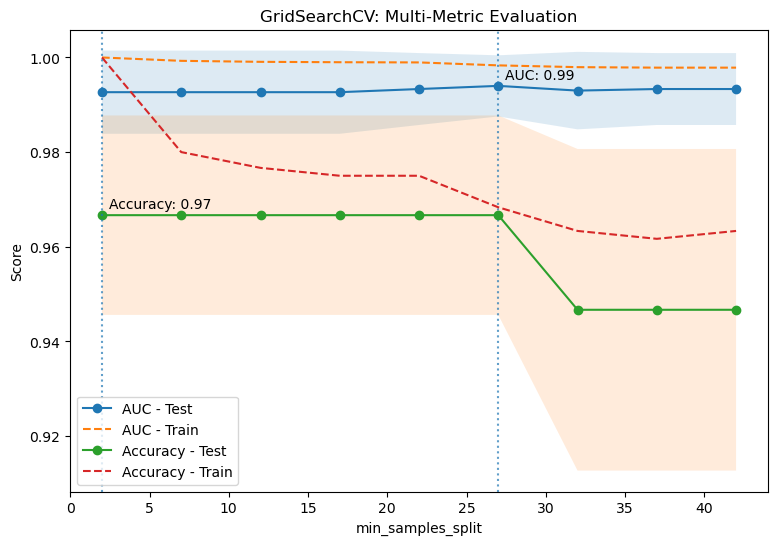

In [8]:
plt.figure(figsize=(9, 6))
plt.title('GridSearchCV: Multi-Metric Evaluation')
plt.xlabel('min_samples_split')
plt.ylabel('Score')

X_axis = np.array(results['param_min_samples_split'], dtype=float)

for scorer in ['AUC', 'Accuracy']:
    mean_test = results[f'mean_test_{scorer}']
    std_test = results[f'std_test_{scorer}']
    mean_train = results[f'mean_train_{scorer}']

    plt.plot(X_axis, mean_test, marker='o', label=f'{scorer} - Test')
    plt.plot(X_axis, mean_train, linestyle='--', label=f'{scorer} - Train')
    plt.fill_between(
        X_axis,
        mean_test - std_test,
        mean_test + std_test,
        alpha=0.15
    )

    best_index = np.argmax(mean_test)
    best_score = mean_test[best_index]
    plt.axvline(X_axis[best_index], linestyle=':', alpha=0.7)
    plt.annotate(
        f'{scorer}: {best_score:.2f}',
        (X_axis[best_index], best_score),
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.legend()
plt.grid(False)
plt.show()

## Conclusion

`GridSearchCV` tests different hyperparameter values using cross-validation. Here, the model is evaluated using **two metrics at the same time: ROC AUC and Accuracy**. The `refit='AUC'` option tells GridSearchCV to select the final best model based on ROC AUC.